# 04 — Reproducing the Sudoku paper

**Paper:** `https://ceur-ws.org/Vol-3432/paper19.pdf`

The aim of this notebook is to reproduce the Sudoku paper by Morra et al., which applies LTNs to verify whether a sudoku problem is right or not. The authors share the code at: https://github.com/MalumaDev/SymbolicSudoku

**The problem:** As the paper explains, a Sudoku “puzzle” or “board” consists of 9 × 9 grid, in which each cell is populated with digits 1–9. Apuzzle is correctly solved if no row, column, or non-overlapping 3×3 subgrid (or “square”) contains all the possible numbers without repetitions. The ViSudo-PC benchmark generalizes the concept of Sudoku puzzles assuming that the board is a square of dimension 𝑚 = 𝑛 × 𝑛 (specifically, 4 × 4 and 9 × 9 grids are provided), and that symbols can come from arbitrary domains. It includes four domains of increasing complexity: digits (MNIST), English letters (EMNIST), fashion items (FashionMNIST), and Japanese characters (KMNIST). In the following, we will refer for simplicity and without loss of generality to the symbols as digits. In order to understand the problem, it is also recomendable reading the original benchmark defined in the paper "Visual Sudoku Puzzle Classification: A Suite of
Collective Neuro-Symbolic Tasks" by Augustine et .al. It can be found at https://par.nsf.gov/servlets/purl/10440135. As this last paper mentions,the aim of this benchmark was to apply NeSy in a problema that:
* 1) include selfcontained symbolic and subsymbolic information, both of which are necessary to solve the problem;
* 2) contain settings/tasks with varying degrees of hardness;
* 3) include entities that can be collectively reasoned over; and
* 4) have unambiguous labels.

Therefore, Augustine's paper defines that "performing well on the
classification of visual Sudoku puzzles requires systems that are able to reason about the perceptual information in the images as well as the collective information from Sudoku constraints.". This is why ViSudo-PC expands upon the perceptual challenge of previous MNIST compositional tasks by drawing images from four different sources. Additionally, ViSudo-PC includes a collection of progressively harder tasks.
**Dataset publicly available at:**:
 Main directory: https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/
 "mnist4": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::4_datasets::mnist_strategy::simple.zip",
    "mnist9": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::9_datasets::mnist_strategy::simple.zip",
    "emnist4": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::4_datasets::emnist_strategy::simple.zip",
    "emnist9": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::9_datasets::emnist_strategy::simple.zip",
    "fmnist4": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::4_datasets::fmnist_strategy::simple.zip",
    "fmnist9": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::9_datasets::fmnist_strategy::simple.zip",
    "kmnist4": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::4_datasets::kmnist_strategy::simple.zip",
    "kmnist9": "https://linqs-data.soe.ucsc.edu/public/datasets/ViSudo-PC/v01/ViSudo-PC_dimension::9_datasets::kmnist_strategy::simple.zip"

Dataset generation code available at: https://github.com/linqs/visual-sudoku-puzzle-classification

For this notebook, we will start with the simplest dataset, the MNIST dataset.



## 1. Loading the dataset

We use our `DataLoader` class, which downloads the dataset on first run (≈50 MB for mnist4)
and returns three `tf.data.Dataset` objects.

Each batch contains:
- `puzzle_images` — `(batch, n_cells, 28, 28, 1)` normalised float32
- `cell_labels`   — `(batch, n_cells)` int32, the true digit in each cell (1-indexed)
- `puzzle_labels` — `(batch,)` int32, 1 = valid sudoku, 0 = invalid

In [1]:
import sys
import os

_sudoku_dir = r"C:\MGEP Dropbox\Aitor Aguirre Ortuzar\Ikerketa\IAExplicable\NeuroSymbolicAI\LTN\logictensornetworks-master\logictensornetworks-master\learn\sudoku"
if _sudoku_dir not in sys.path:
    sys.path.insert(0, _sudoku_dir)
os.chdir(_sudoku_dir)

from DataLoader import DataLoader

loader = DataLoader(dataset_name="mnist4", split=0, batch_size=32)
train_ds, val_ds, test_ds, n_classes = loader.load_dataset()

print(f"n_classes: {n_classes}")

labels  [train]:   0%|          | 0/2 [00:00<?, ?it/s]

puzzles [train]:   0%|          | 0/2 [00:00<?, ?it/s]

pixels  [train]:   0%|          | 0/2 [00:00<?, ?it/s]

labels  [train]:   0%|          | 0/4 [00:00<?, ?it/s]

puzzles [train]:   0%|          | 0/4 [00:00<?, ?it/s]

...

pixels  [test]:   0%|          | 0/100 [00:00<?, ?it/s]

labels  [test]:   0%|          | 0/100 [00:00<?, ?it/s]

puzzles [test]:   0%|          | 0/100 [00:00<?, ?it/s]

pixels  [test]:   0%|          | 0/100 [00:00<?, ?it/s]

n_classes: 4


## 2. Inspecting a batch

Let's take one batch and check the shapes and value ranges.

In [2]:
for puzzle_images, cell_labels, puzzle_labels in train_ds.take(1):
    print("puzzle_images :", puzzle_images.shape, puzzle_images.dtype)
    print("  min/max      :", float(puzzle_images.numpy().min()), float(puzzle_images.numpy().max()))
    print("cell_labels   :", cell_labels.shape,   cell_labels.dtype)
    print("  unique values:", sorted(set(cell_labels.numpy().flatten().tolist())))
    print("puzzle_labels :", puzzle_labels.shape,  puzzle_labels.dtype)
    print("  values       :", puzzle_labels.numpy().tolist())

puzzle_images : (32, 16, 28, 28, 1) <dtype: 'float32'>
  min/max      : -0.4242129623889923 2.821486711502075
cell_labels   : (32, 16) <dtype: 'int32'>
  unique values: [0, 1, 2, 3]
puzzle_labels : (32,) <dtype: 'int32'>
  values       : [0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1]


## 3. Visualising one puzzle

Each puzzle is a 4×4 grid of 28×28 digit images.
We reverse the normalisation to display them.

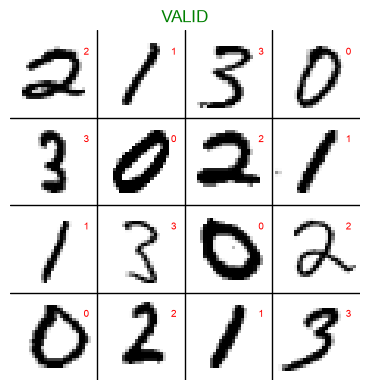

In [3]:
from utils import show_puzzle

for puzzle_images, cell_labels, puzzle_labels in train_ds.take(1):
    imgs   = puzzle_images[0].numpy()
    labels = cell_labels[0].numpy()
    valid  = int(puzzle_labels[0].numpy())

    show_puzzle(imgs, cell_labels=labels, puzzle_label=valid)

In [4]:
puzzle_labels.numpy()

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0], dtype=int32)

In [5]:
cell_labels[0]


<tf.Tensor: shape=(16,), dtype=int32, numpy=array([2, 1, 3, 0, 3, 0, 2, 1, 1, 3, 0, 2, 0, 2, 1, 3], dtype=int32)>

In [6]:
# Baseline CNN — classifies individual cell images into digits
# We train on cell-level labels (which digit is in each cell)
# and evaluate on puzzle-level validity via a rule checker

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

# ── Model ──────────────────────────────────────────────────────────────────
model = Sequential([
    Conv2D(filters=8,  kernel_size=(5,5), padding='same', activation='relu',
           input_shape=(28, 28, 1)),
    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2), strides=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax'),   # n_classes=4 for mnist4
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',   # labels are integers, not one-hot
    metrics=['accuracy']
)

model.summary()

# ── Data preparation ────────────────────────────────────────────────────────
# train_ds yields (puzzle_images, cell_labels, puzzle_labels)
#   puzzle_images : (batch, n_cells, 28, 28, 1)
#   cell_labels   : (batch, n_cells)              integers 0..n_classes-1
#
# The CNN needs individual cells: reshape each batch into
#   images : (batch * n_cells, 28, 28, 1)
#   labels : (batch * n_cells,)

def flatten_to_cells(puzzle_images, cell_labels, puzzle_labels):
    batch = tf.shape(puzzle_images)[0]
    images = tf.reshape(puzzle_images, (batch * n_classes * n_classes, 28, 28, 1))
    labels = tf.reshape(cell_labels,   (batch * n_classes * n_classes,))
    return images, labels

cell_train_ds = train_ds.map(flatten_to_cells).unbatch().batch(256).prefetch(tf.data.AUTOTUNE)
cell_val_ds   = val_ds.map(flatten_to_cells).unbatch().batch(256).prefetch(tf.data.AUTOTUNE)

# ── Training ────────────────────────────────────────────────────────────────
history = model.fit(
    cell_train_ds,
    epochs=20,
    validation_data=cell_val_ds,
)

C:\Users\aaguirre\AppData\Local\miniconda3\envs\ltn_tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,364 (794.39 KB)

 Trainable params: 203,364 (794.39 KB)

...

Epoch 1/20


C:\Users\aaguirre\AppData\Local\miniconda3\envs\ltn_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


     32/Unknown 6s 30ms/step - accuracy: 0.8143 - loss: 0.4917

C:\Users\aaguirre\AppData\Local\miniconda3\envs\ltn_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8156 - loss: 0.4884 - val_accuracy: 0.9664 - val_loss: 0.1184
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9541 - loss: 0.1322 - val_accuracy: 0.9765 - val_loss: 0.0779
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9686 - loss: 0.0910 - val_accuracy: 0.9772 - val_loss: 0.0697
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9763 - loss: 0.0702 - val_accuracy: 0.9801 - val_loss: 0.0582
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9829 - loss: 0.0541 - val_accuracy: 0.9852 - val_loss: 0.0462
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9826 - loss: 0.0537 - val_accuracy: 0.9867 - val_loss: 0.0423
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9864 - loss: 0.0394 - val_accuracy: 0.9887 - val_loss: 0.0374
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9863 - loss: 0.0377 - val_accuracy: 0.9894 - val_loss: 0.

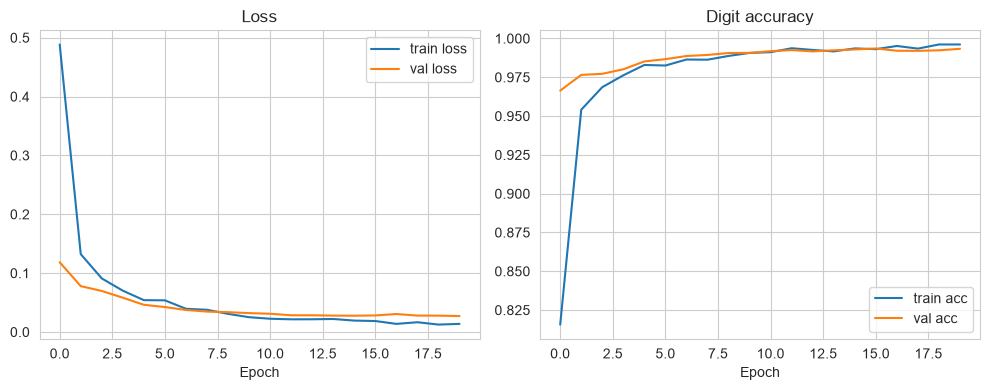

In [7]:
# Training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Digit accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.tight_layout(); plt.show()

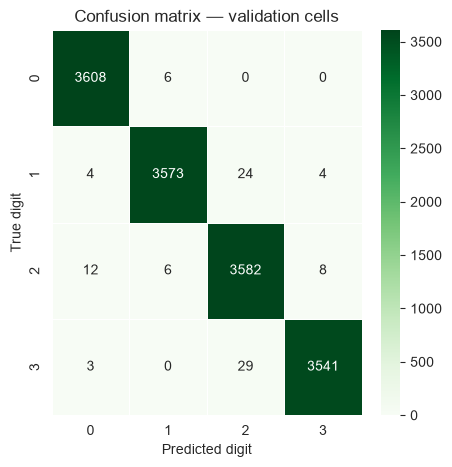

Cell-level accuracy: 0.993


In [8]:
# Confusion matrix on validation cells
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Collect all predictions and true labels from the validation set
y_true, y_pred = [], []
for images, labels in cell_val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=0.5,
            xticklabels=range(n_classes), yticklabels=range(n_classes), ax=ax)
plt.xlabel('Predicted digit'); plt.ylabel('True digit')
plt.title('Confusion matrix — validation cells')
plt.show()

print(f"Cell-level accuracy: {(y_true == y_pred).mean():.3f}")

## 5. Puzzle-level accuracy (CNN baseline)

Cell-level accuracy (~99%) does not directly tell us puzzle-level accuracy.
A single wrong cell prediction can flip the sudoku validity result.
We use `CNN_Puzzle_Is_Valid` to predict validity from CNN digit predictions
and compare against the ground-truth `puzzle_labels`.

In [9]:
from utils import CNN_Puzzle_Is_Valid, is_valid_sudoku

correct = 0
total   = 0

for puzzle_images, cell_labels, puzzle_labels in test_ds:
    for i in range(len(puzzle_labels)):
        cnn_valid  = CNN_Puzzle_Is_Valid(model, puzzle_images[i].numpy())
        real_valid = int(puzzle_labels[i].numpy()) == 1
        if cnn_valid == real_valid:
            correct += 1
        total += 1

print(f"Puzzle-level accuracy: {correct}/{total} = {correct/total:.3f}")

Puzzle-level accuracy: 851/900 = 0.946


We got 851 sudokus right out of 900 in 4x4 puzzles. Let's proceed with the symbolic approach to check if we can improve this result.